# A2 EDA, part 1 of 2 - inventory, join, gear

Silver interactions and vessels only. This half answers: **what is the table, and who fishes?**

Part 2 (later): seasonality, top regions, quality surprises (hours > 24, MMSIs active more than a calendar year, non-9-digit MMSIs).

Exploration lives here. No pipeline logic, no transit drop, no spatial join.


## Conventions

- Read `data/processed/interactions/` and `data/processed/vessels.parquet` (silver).
- `hive_partitioning=false` so `year` / `month` stay the integer columns silver wrote.
- Vessel join is **`(mmsi, year)`**. GFW v3 is one row per MMSI per year; joining on MMSI alone fans out rows.
- `fishing_ratio` stays in the table. Low-ratio steaming lanes are a finding, not a filter (B1).


In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

from src.paths import INTERACTIONS_DIR, VESSELS_PATH

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")

INTERACTIONS = (INTERACTIONS_DIR.as_posix() + "/**/*.parquet")
VESSELS = VESSELS_PATH.as_posix()

assert INTERACTIONS_DIR.exists(), INTERACTIONS_DIR
assert VESSELS_PATH.exists(), VESSELS_PATH
print("interactions", INTERACTIONS_DIR)
print("vessels     ", VESSELS_PATH)


interactions C:\Users\isvan\OneDrive\Documents\Van-Cave\Machine Learning\Fisheries\data\processed\interactions
vessels      C:\Users\isvan\OneDrive\Documents\Van-Cave\Machine Learning\Fisheries\data\processed\vessels.parquet


## 1. Inventory

One row is a vessel × 0.1° cell × day. `hours` is AIS presence; `fishing_hours` is the subset GFW labelled as fishing.


In [2]:
inventory = con.execute(
    """
    SELECT
      year,
      count(*) AS rows,
      count(DISTINCT mmsi) AS vessels,
      count(DISTINCT cell_id) AS cells,
      min(date) AS min_date,
      max(date) AS max_date,
      round(sum(hours), 1) AS hours,
      round(sum(fishing_hours), 1) AS fishing_hours,
      round(100.0 * sum(fishing_hours) / nullif(sum(hours), 0), 2) AS fishing_pct_of_presence
    FROM read_parquet(?, hive_partitioning = false)
    GROUP BY 1
    ORDER BY 1
    """,
    [INTERACTIONS],
).df()

totals = con.execute(
    """
    SELECT
      count(*) AS rows,
      count(DISTINCT mmsi) AS vessels,
      count(DISTINCT cell_id) AS cells,
      round(sum(hours), 1) AS hours,
      round(sum(fishing_hours), 1) AS fishing_hours
    FROM read_parquet(?, hive_partitioning = false)
    """,
    [INTERACTIONS],
).df()

display(inventory)
display(totals)


,year,rows,vessels,cells,min_date,max_date,hours,fishing_hours,fishing_pct_of_presence
0,2023,84786933,96453,2040786,2023-01-01,2023-12-31,283508910.7,111710765.8,39.40
1,2024,84800259,94459,2002622,2024-01-01,2024-12-31,299056335.8,114380457.9,38.25


,rows,vessels,cells,hours,fishing_hours
0,169587192,117081,2341624,582565246.4,226091223.8


,bucket,rows,hours,fishing_hours
0,0,100048380,299234194.6,0.0
1,"(0, 0.05]",892076,11696101.3,279520.8
2,"(0.05, 0.25]",3160696,21924123.9,2981679.7
3,"(0.25, 0.50]",4197195,18549003.8,6974904.3
4,"(0.50, 0.90]",12674502,52375936.8,38715817.7
5,"(0.90, 1]",48614343,178785886.1,177139301.2


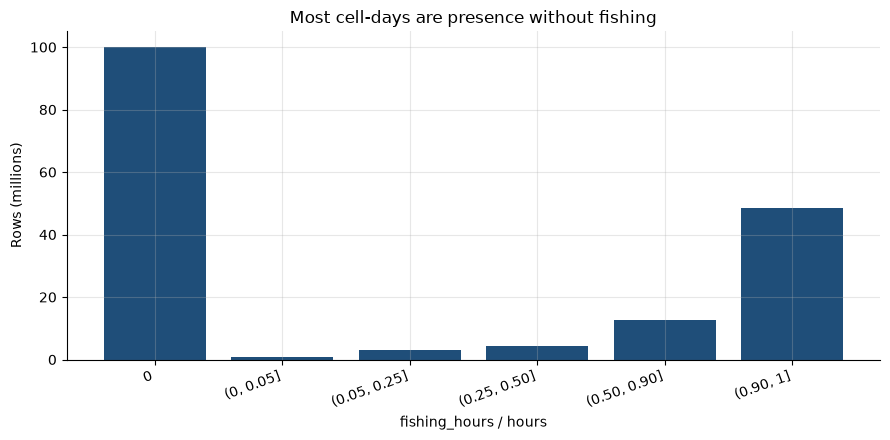

In [3]:
ratio_buckets = con.execute(
    """
    SELECT
      CASE
        WHEN fishing_ratio = 0 THEN '0'
        WHEN fishing_ratio <= 0.05 THEN '(0, 0.05]'
        WHEN fishing_ratio <= 0.25 THEN '(0.05, 0.25]'
        WHEN fishing_ratio <= 0.50 THEN '(0.25, 0.50]'
        WHEN fishing_ratio <= 0.90 THEN '(0.50, 0.90]'
        ELSE '(0.90, 1]'
      END AS bucket,
      count(*) AS rows,
      round(sum(hours), 1) AS hours,
      round(sum(fishing_hours), 1) AS fishing_hours
    FROM read_parquet(?, hive_partitioning = false)
    GROUP BY 1
    ORDER BY min(fishing_ratio)
    """,
    [INTERACTIONS],
).df()

display(ratio_buckets)

fig, ax = plt.subplots()
ax.bar(ratio_buckets["bucket"], ratio_buckets["rows"] / 1_000_000, color="#1f4e79")
ax.set_ylabel("Rows (millions)")
ax.set_xlabel("fishing_hours / hours")
ax.set_title("Most cell-days are presence without fishing")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### Findings — inventory

- Two full years, almost the same size: **84.8M rows each**. 2023: 96,453 MMSIs and 2.04M cells; 2024: 94,459 MMSIs and 2.00M cells. Distinct MMSIs across both years are about **117k**, so a large share of vessels appear in both years.
- Presence hours are **283.5M (2023)** and **299.1M (2024)**. Fishing is **39.4%** and **38.3%** of presence respectively. 2024 has more presence hours and slightly less fishing share — treat year-on-year “effort up” as provisional (AIS coverage is non-stationary; 2024 classifications are provisional).
- **~100M rows (59%) have `fishing_ratio = 0`.** Those are steaming / sitting, not grounds. Another **48.6M rows** are almost pure fishing (`ratio > 0.9`). The interaction matrix (B1) will need a ratio threshold; this histogram is why. Do not drop them here — EDA still needs the transit mass.


## 2. Vessel join

GFW v3 is one metadata row per MMSI **per year**. Join on both keys or the interaction table fans out.


In [4]:
join_coverage = con.execute(
    """
    WITH i AS (
      SELECT mmsi, year, hours, fishing_hours
      FROM read_parquet(?, hive_partitioning = false)
    )
    SELECT
      count(*) AS rows,
      count(*) FILTER (WHERE v.mmsi IS NULL) AS unmatched_rows,
      round(100.0 * count(*) FILTER (WHERE v.mmsi IS NULL) / count(*), 4) AS unmatched_row_pct,
      count(DISTINCT i.mmsi) AS interaction_mmsis,
      count(DISTINCT i.mmsi) FILTER (WHERE v.mmsi IS NULL) AS unmatched_mmsis
    FROM i
    LEFT JOIN read_parquet(?) v ON i.mmsi = v.mmsi AND i.year = v.year
    """,
    [INTERACTIONS, VESSELS],
).df()

unmatched = con.execute(
    """
    WITH i AS (
      SELECT DISTINCT mmsi, year
      FROM read_parquet(?, hive_partitioning = false)
    )
    SELECT i.mmsi, i.year
    FROM i
    LEFT JOIN read_parquet(?) v ON i.mmsi = v.mmsi AND i.year = v.year
    WHERE v.mmsi IS NULL
    ORDER BY i.year, i.mmsi
    """,
    [INTERACTIONS, VESSELS],
).df()

display(join_coverage)
display(unmatched)


,rows,unmatched_rows,unmatched_row_pct,interaction_mmsis,unmatched_mmsis
0,169587192,13879,0.0082,117081,3


,mmsi,year
0,273873400,2023
1,412217999,2023
2,431002015,2023
3,273873400,2024
4,431002015,2024


### Findings — join

- **13,879 unmatched rows (0.008%)** and **3 unmatched MMSIs**. Gear charts below label those as `(unmatched)` rather than dropping them.
- The join is safe at this grain. The v3 fan-out warning in DATA.md is real for a sloppy join, not for `(mmsi, year)`.


## 3. Effort by gear

`vessel_class_gfw` is the strongest metadata field. If a later ALS latent space does not roughly separate these classes, the model is wrong.


,gear,rows,vessels,fishing_hours,hours,fishing_share_pct
0,trawlers,70208122,48436,120382763.7,247276689.7,53.245217
1,fishing,27915809,24587,38695432.9,126227499.9,17.114965
2,drifting_longlines,26435680,8162,25299648.3,49623777.5,11.190018
3,set_gillnets,8906360,10602,12339950.6,45510762.6,5.457952
4,set_longlines,8375284,8512,10699315.4,28476779.9,4.732300
5,fixed_gear,5104811,5011,6627654.0,23173619.1,2.931407
6,squid_jigger,6799998,1325,3032030.4,12863029.0,1.341065
7,other_purse_seines,6214915,3423,2613250.8,18347437.2,1.155839
8,pole_and_line,3353120,2745,2337178.4,10460710.3,1.033732
9,dredge_fishing,992484,1895,1645308.2,6228956.1,0.727719


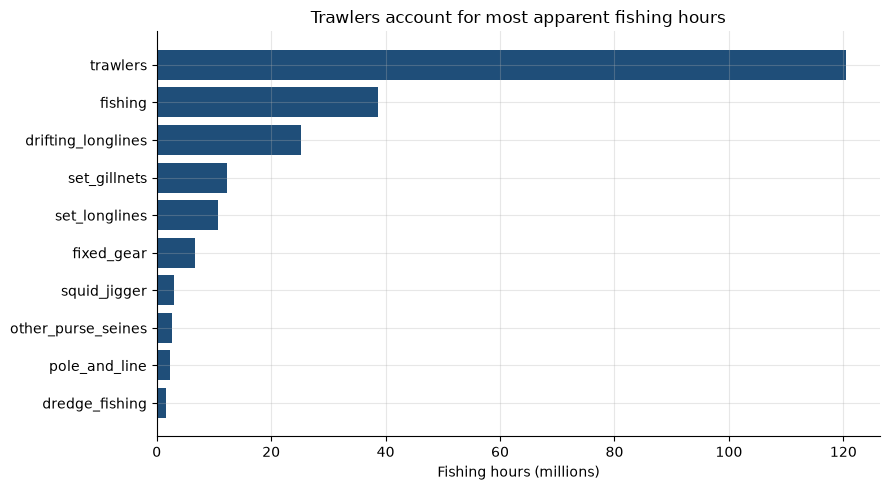

In [5]:
gear = con.execute(
    """
    WITH i AS (
      SELECT mmsi, year, hours, fishing_hours
      FROM read_parquet(?, hive_partitioning = false)
    )
    SELECT
      coalesce(v.vessel_class_gfw, '(unmatched)') AS gear,
      count(*) AS rows,
      count(DISTINCT i.mmsi) AS vessels,
      round(sum(i.fishing_hours), 1) AS fishing_hours,
      round(sum(i.hours), 1) AS hours
    FROM i
    LEFT JOIN read_parquet(?) v ON i.mmsi = v.mmsi AND i.year = v.year
    GROUP BY 1
    ORDER BY fishing_hours DESC
    """,
    [INTERACTIONS, VESSELS],
).df()

gear["fishing_share_pct"] = 100.0 * gear["fishing_hours"] / gear["fishing_hours"].sum()
display(gear)

top = gear.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top["gear"], top["fishing_hours"] / 1_000_000, color="#1f4e79")
ax.set_xlabel("Fishing hours (millions)")
ax.set_title("Trawlers account for most apparent fishing hours")
plt.tight_layout()
plt.show()


### Findings - gear

- **Trawlers: 53% of fishing hours** (120.4M of 226.1M) from 48k vessels. They will dominate a global-popularity baseline. Popularity-by-gear is the baseline that matters; ALS has to beat *trawlers fish the shelf*, not a flat top-N over all gears.
- Next are the generic class **`fishing`** (38.7M h, 24.6k vessels) and **`drifting_longlines`** (25.3M h, only 8.2k vessels - high hours per hull). Set gillnets and set longlines follow.
- **Rare gears** (trollers, other_seines, seiners, purse_seines) are small in hours. Cold-start and coverage metrics should not pretend they have the same support as trawlers. `(unmatched)` is negligible (5.9k fishing hours).
- `fishing` as a class is a GFW leftover bucket, not a gear. Treat it as low-information metadata, not as a behavioural type.
